In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.read_csv(DATA_DIR / "decision_tree_dataset.csv", encoding="utf-8-sig")
df = df.rename(columns={"Unnamed: 5": "target"})
df["target"] = df["target"].str.strip().str.lower()
display(df.head())
display(df["target"].value_counts().rename_axis("target").reset_index(name="count"))

,1,2,3,4,sum,target
0,201,10018,250,3046,13515,yes
1,205,10016,395,3044,13660,yes
2,257,10129,109,3251,13746,yes
3,246,10064,324,3137,13771,yes
4,117,10115,496,3094,13822,yes


,target,count
0,no,521
1,yes,479


Accuracy: 1.000
              precision    recall  f1-score   support

          no       1.00      1.00      1.00       130
         yes       1.00      1.00      1.00       120

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



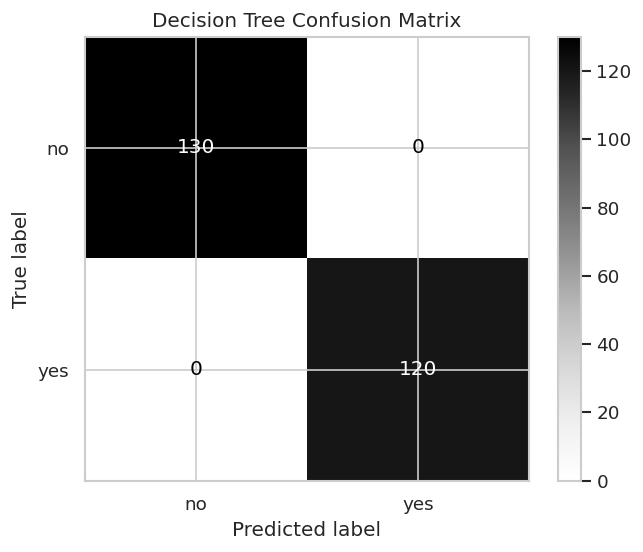

,feature,importance
4,sum,1.0
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0


In [3]:
feature_cols = ["1", "2", "3", "4", "sum"]
X = df[feature_cols]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)
pred = tree.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Greys")
plt.title("Decision Tree Confusion Matrix")
plt.show()

importance = pd.DataFrame(
    {"feature": feature_cols, "importance": tree.feature_importances_}
).sort_values("importance", ascending=False)
display(importance)

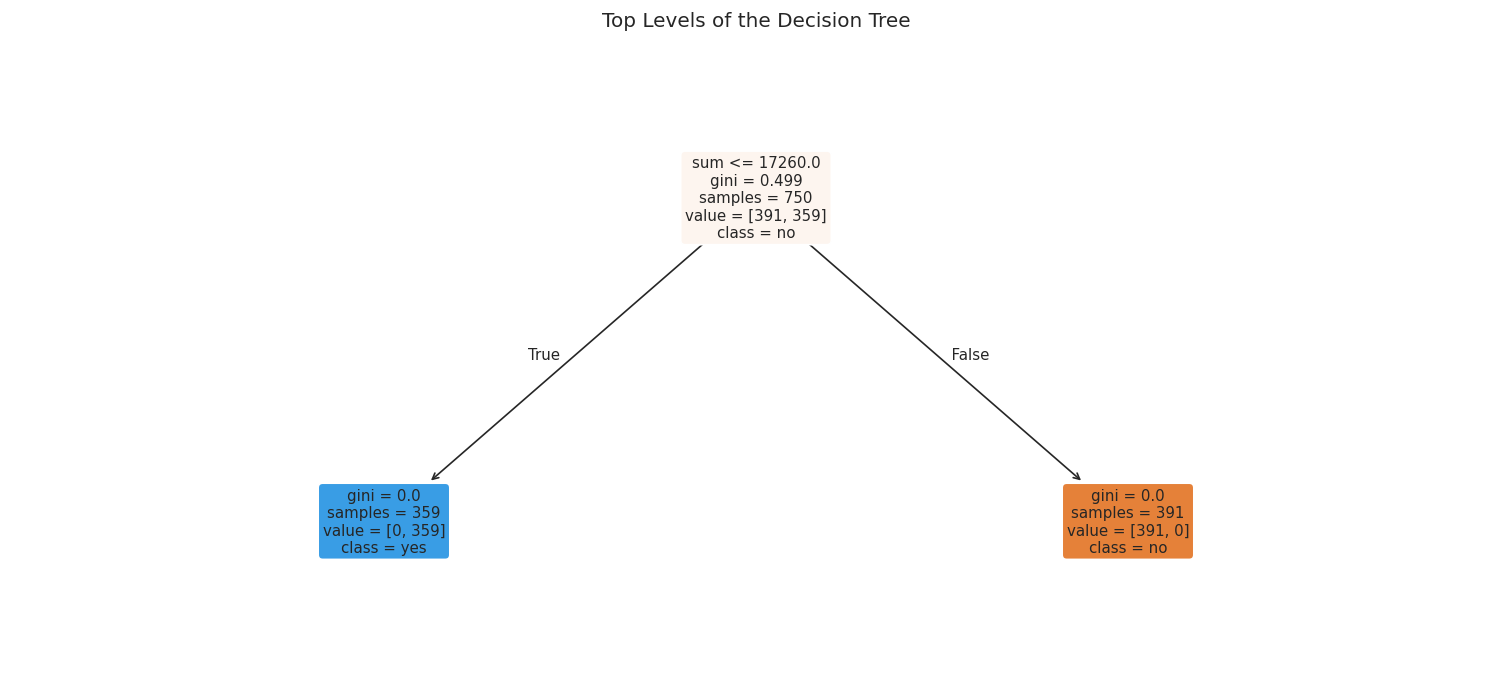

In [4]:
plt.figure(figsize=(16, 7))
plot_tree(
    tree,
    feature_names=feature_cols,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Top Levels of the Decision Tree")
plt.show()